# Gold Price Modeling Project with Transformer Sentiment from Artificial Text




## Executive summary

This project evaluates whether daily gold market data can be used to predict the next trading day's direction. The focus is on **ensemble learning**, using multiple models together to improve predictive performance compared with single classifiers. The workflow includes cleaning the data, creating lagged and rolling features, building a binary target for next-day direction, tuning models with time-aware cross-validation, and comparing several ensemble techniques.

## Rationale

Gold is often treated as a defensive asset and an inflation hedge, so even small improvements in directional forecasting may be useful for trading discipline, market monitoring, and feature selection. This project matters because it applies a structured machine learning workflow to a real financial dataset and tests whether ensemble models can capture signal more effectively than standalone methods.

## Research Question

Can historical gold price and volume data be used to predict whether the next day's closing price will increase, and which ensemble method performs best on that task?

## Data Sources

The analysis uses `finalgolddata.csv`, which contains daily gold market observations with these variables:

- `Date`
- `Open`
- `High`
- `Low`
- `Close`
- `Volume`

This revised version also adds sentiment-style market features from an artificial gold sentiment CSV. The artificial sentiment file is merged into the gold price data by date so the ensemble models can test whether sentiment variables improve prediction.

## Methodology

This project uses the following modeling workflow:

1. Load and clean the daily gold dataset.
2. Add artificial gold sentiment features from `artificial_gold_news_text.csv`.
3. Parse dates and preserve time order.
4. Engineer lagged and rolling features from price and volume.
5. Create a binary target equal to 1 when the next day's close is greater than the current day's close.
6. Split the data into training and test sets using time order.
7. Tune multiple base learners with `GridSearchCV` and `TimeSeriesSplit`.
8. Compare ensemble methods:
   - AdaBoost
   - Bagging
   - Soft Voting
   - Stacking
9. Evaluate models with accuracy, precision, recall, F1, and ROC-AUC.
10. Perform same evaluation with RNN
11. Compare scores for model selection

## Setup

## Colab setup
Run this cell first. The notebook only needs the standard modeling packages because sentiment data is loaded from the artificial CSV.

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib transformers torch tensorflow


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from pathlib import Path
from datetime import timedelta

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

from transformers import pipeline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Copy entire folder from Google Drive to Colab /content

!cp -r "/content/drive/MyDrive/Capstone/data/" /content/data

In [5]:
!ls /content/data

artificial_gold_news_text.csv	    finalgolddata.csv
artificial_gold_sentiment_data.csv


## Transformer sentiment analysis from artificial text data

This section loads artificial gold-related news headlines, applies a transformer sentiment model, 
converts the text labels into numeric features, aggregates them by date, and prepares them for merging with the gold price data.

In [6]:


news_path = Path('/content/data/artificial_gold_news_text.csv')
news_df = pd.read_csv(news_path)
news_df['date'] = pd.to_datetime(news_df['date'])

# A general transformer sentiment model. This keeps the notebook simple for Colab.
# It classifies text as POSITIVE or NEGATIVE. We map positive language to bullish sentiment
# and negative language to bearish sentiment.
sentiment_model = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)

def transformer_sentiment(text):
    result = sentiment_model(str(text)[:512])[0]
    label = result['label'].lower()
    confidence = result['score']
    if label == 'positive':
        score = 1
    elif label == 'negative':
        score = -1
    else:
        score = 0
    return pd.Series([label, confidence, score])

news_df[['transformer_label', 'sentiment_confidence', 'sentiment_score']] = news_df['headline'].apply(transformer_sentiment)

daily_sentiment = news_df.groupby('date').agg(
    avg_sentiment=('sentiment_score', 'mean'),
    bullish_count=('sentiment_score', lambda x: (x == 1).sum()),
    bearish_count=('sentiment_score', lambda x: (x == -1).sum()),
    neutral_count=('sentiment_score', lambda x: (x == 0).sum()),
    headline_count=('headline', 'count'),
    avg_sentiment_confidence=('sentiment_confidence', 'mean')
).reset_index()

daily_sentiment['sentiment_3_day'] = daily_sentiment['avg_sentiment'].rolling(3, min_periods=1).mean()
daily_sentiment['sentiment_7_day'] = daily_sentiment['avg_sentiment'].rolling(7, min_periods=1).mean()

display(news_df.head())
display(daily_sentiment.head())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,date,headline,expected_sentiment,transformer_label,sentiment_confidence,sentiment_score
0,2000-01-09,Gold retreats as risk appetite improves across...,bearish,negative,0.976231,-1
1,2000-01-11,Gold trades mostly flat as markets wait for Fe...,neutral,negative,0.999748,-1
2,2000-01-12,Gold prices climb as traders expect lower inte...,bullish,negative,0.988104,-1
3,2000-02-10,Gold market shows limited movement as volume r...,neutral,negative,0.997411,-1
4,2000-02-11,Gold holds near recent levels during quiet mar...,neutral,positive,0.985017,1


,date,avg_sentiment,bullish_count,bearish_count,neutral_count,headline_count,avg_sentiment_confidence,sentiment_3_day,sentiment_7_day
0,2000-01-09,-1.0,0,1,0,1,0.976231,-1.000000,-1.0
1,2000-01-11,-1.0,0,1,0,1,0.999748,-1.000000,-1.0
2,2000-01-12,-1.0,0,1,0,1,0.988104,-1.000000,-1.0
3,2000-02-10,-1.0,0,1,0,1,0.997411,-1.000000,-1.0
4,2000-02-11,1.0,1,0,0,1,0.985017,-0.333333,-0.6


## Merge transformer sentiment features with gold data

The transformer-generated daily sentiment features are merged into the gold price dataset by date.

In [7]:
# Load gold data and merge with transformer-created sentiment features
gold_path = Path('/content/data/finalgolddata.csv')
gold_df = pd.read_csv(gold_path)

# Find date column robustly
date_candidates = [c for c in gold_df.columns if c.lower() in ['date', 'time', 'datetime']]
if not date_candidates:
    raise ValueError('No date column found. Rename your date column to date, Date, time, or datetime.')
gold_date_col = date_candidates[0]
gold_df[gold_date_col] = pd.to_datetime(gold_df[gold_date_col])
gold_df = gold_df.rename(columns={gold_date_col: 'date'})

gold_df = gold_df.merge(daily_sentiment, on='date', how='left')

sentiment_cols = [
    'avg_sentiment', 'bullish_count', 'bearish_count', 'neutral_count',
    'headline_count', 'avg_sentiment_confidence', 'sentiment_3_day', 'sentiment_7_day'
]
gold_df[sentiment_cols] = gold_df[sentiment_cols].fillna(0)

print(gold_df.shape)
display(gold_df[['date'] + sentiment_cols].head())


/tmp/ipykernel_1023/918507874.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gold_df[gold_date_col] = pd.to_datetime(gold_df[gold_date_col])


(6399, 14)


,date,avg_sentiment,bullish_count,bearish_count,neutral_count,headline_count,avg_sentiment_confidence,sentiment_3_day,sentiment_7_day
0,2000-08-30,1.0,1.0,0.0,0.0,1.0,0.986507,0.333333,-0.142857
1,2000-08-31,1.0,1.0,0.0,0.0,1.0,0.984478,0.333333,0.142857
2,2000-01-09,-1.0,0.0,1.0,0.0,1.0,0.976231,-1.000000,-1.000000
3,2000-05-09,1.0,1.0,0.0,0.0,1.0,0.989997,-0.333333,-0.142857
4,2000-06-09,1.0,1.0,0.0,0.0,1.0,0.985017,0.333333,0.142857


In [8]:
gold_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6399 entries, 0 to 6398
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      6399 non-null   datetime64[ns]
 1   Open                      6399 non-null   float64       
 2   High                      6399 non-null   float64       
 3   Low                       6399 non-null   float64       
 4   Close                     6399 non-null   float64       
 5   Volume                    6399 non-null   int64         
 6   avg_sentiment             6399 non-null   float64       
 7   bullish_count             6399 non-null   float64       
 8   bearish_count             6399 non-null   float64       
 9   neutral_count             6399 non-null   float64       
 10  headline_count            6399 non-null   float64       
 11  avg_sentiment_confidence  6399 non-null   float64       
 12  sentiment_3_day     

## Feature engineering

In [9]:

df = gold_df.copy()
# Make sure numeric market columns are numeric.
price_cols = ["Open", "High", "Low", "Close", "Volume"]
for col in price_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Basic price behavior
df["daily_return"] = df["Close"].pct_change()
df["open_close_return"] = (df["Close"] - df["Open"]) / df["Open"]
df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"]

# Rolling trend features
df["ma_5"] = df["Close"].rolling(5).mean()
df["ma_10"] = df["Close"].rolling(10).mean()
df["ma_20"] = df["Close"].rolling(20).mean()

# Distance from moving averages
df["close_vs_ma_5"] = (df["Close"] / df["ma_5"]) - 1
df["close_vs_ma_10"] = (df["Close"] / df["ma_10"]) - 1
df["close_vs_ma_20"] = (df["Close"] / df["ma_20"]) - 1

# Volatility and momentum
df["volatility_5"] = df["daily_return"].rolling(5).std()
df["volatility_10"] = df["daily_return"].rolling(10).std()
df["momentum_3"] = df["Close"].pct_change(3)
df["momentum_5"] = df["Close"].pct_change(5)
df["momentum_10"] = df["Close"].pct_change(10)

# Volume features
df["volume_change"] = df["Volume"].pct_change()
df["volume_ma_5"] = df["Volume"].rolling(5).mean()
df["volume_ma_10"] = df["Volume"].rolling(10).mean()

# Lagged features
lag_cols = ["Close", "Volume", "daily_return", "high_low_range", "momentum_3", "momentum_5"]
for col in lag_cols:
    for lag in [1, 2, 3, 5]:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)

# Sentiment columns were created earlier by the transformer and merged into gold_df.
sentiment_cols = [
    "avg_sentiment", "bullish_count", "bearish_count", "neutral_count",
    "headline_count", "avg_sentiment_confidence", "sentiment_3_day", "sentiment_7_day"
]
available_sentiment_cols = [col for col in sentiment_cols if col in df.columns]
df[available_sentiment_cols] = df[available_sentiment_cols].fillna(0)

# Additional rolling sentiment features based on the transformer sentiment already merged.
if "avg_sentiment" in df.columns:
    df["sentiment_14_day"] = df["avg_sentiment"].rolling(14, min_periods=1).mean()
if "headline_count" in df.columns:
    df["headline_count_7_day"] = df["headline_count"].rolling(7, min_periods=1).sum()

# Remove infinity values caused by pct_change or division.
df = df.replace([np.inf, -np.inf], np.nan)

display(df.head())
print("Feature engineered dataframe shape:", df.shape)


,date,Open,High,Low,Close,Volume,avg_sentiment,bullish_count,bearish_count,neutral_count,...,momentum_3_lag_1,momentum_3_lag_2,momentum_3_lag_3,momentum_3_lag_5,momentum_5_lag_1,momentum_5_lag_2,momentum_5_lag_3,momentum_5_lag_5,sentiment_14_day,headline_count_7_day
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.0
1,2000-08-31,274.799988,278.299988,274.799988,278.299988,0,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,2.0
2,2000-01-09,277.000000,277.000000,277.000000,277.000000,0,-1.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,3.0
3,2000-05-09,275.799988,275.799988,275.799988,275.799988,2,1.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,4.0
4,2000-06-09,274.200012,274.200012,274.200012,274.200012,0,1.0,1.0,0.0,0.0,...,0.006937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.600000,5.0


Feature engineered dataframe shape: (6399, 57)


### Sentiment feature note

The sentiment features used below come from the earlier transformer section. The artificial news text is transformed into daily sentiment features, merged into `gold_df`, and then carried forward into `df` during feature engineering.

In [14]:
# Binary target: next day's close is higher than today's close
df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

df_model = df.dropna().copy()

print(df_model.shape)
print("Modeling dataframe columns:", df_model.columns.tolist())
df_model.head()


(5978, 58)
Modeling dataframe columns: ['date', 'Open', 'High', 'Low', 'Close', 'Volume', 'avg_sentiment', 'bullish_count', 'bearish_count', 'neutral_count', 'headline_count', 'avg_sentiment_confidence', 'sentiment_3_day', 'sentiment_7_day', 'daily_return', 'open_close_return', 'high_low_range', 'ma_5', 'ma_10', 'ma_20', 'close_vs_ma_5', 'close_vs_ma_10', 'close_vs_ma_20', 'volatility_5', 'volatility_10', 'momentum_3', 'momentum_5', 'momentum_10', 'volume_change', 'volume_ma_5', 'volume_ma_10', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3', 'Volume_lag_5', 'daily_return_lag_1', 'daily_return_lag_2', 'daily_return_lag_3', 'daily_return_lag_5', 'high_low_range_lag_1', 'high_low_range_lag_2', 'high_low_range_lag_3', 'high_low_range_lag_5', 'momentum_3_lag_1', 'momentum_3_lag_2', 'momentum_3_lag_3', 'momentum_3_lag_5', 'momentum_5_lag_1', 'momentum_5_lag_2', 'momentum_5_lag_3', 'momentum_5_lag_5', 'sentiment_14_day', 'headline_co

,date,Open,High,Low,Close,Volume,avg_sentiment,bullish_count,bearish_count,neutral_count,...,momentum_3_lag_2,momentum_3_lag_3,momentum_3_lag_5,momentum_5_lag_1,momentum_5_lag_2,momentum_5_lag_3,momentum_5_lag_5,sentiment_14_day,headline_count_7_day,target
20,2000-09-28,277.500000,277.500000,275.100006,275.600006,631,-1.0,0.0,1.0,0.0,...,0.013319,0.018959,-0.004053,0.034944,0.007356,0.009948,-0.007709,0.142857,7.0,0
21,2000-09-29,274.600006,274.600006,272.000000,273.600006,22,-1.0,0.0,1.0,0.0,...,0.024283,0.013319,-0.000368,0.019608,0.034944,0.007356,-0.001836,0.142857,7.0,0
22,2000-02-10,272.799988,273.500000,272.500000,273.100006,161,-1.0,0.0,1.0,0.0,...,0.005472,0.024283,0.018959,0.006623,0.019608,0.034944,0.009948,0.000000,7.0,0
23,2000-03-10,272.100006,272.799988,271.500000,271.600006,25,-1.0,0.0,1.0,0.0,...,-0.001095,0.005472,0.013319,-0.003648,0.006623,0.019608,0.007356,0.000000,7.0,0
24,2000-04-10,270.500000,271.000000,270.100006,270.299988,11,-1.0,0.0,1.0,0.0,...,-0.019037,-0.001095,0.024283,-0.008397,-0.003648,0.006623,0.034944,-0.142857,7.0,1


## Exploratory checks

In [11]:
df_model[["Open", "High", "Low", "Close", "Volume", "target"]].describe()


,Open,High,Low,Close,Volume,target
count,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000,5978.000000
mean,1330.347240,1337.623587,1322.904115,1330.406272,4384.536802,0.531114
std,771.678608,777.545050,765.987036,771.936317,24504.699929,0.499073
min,255.000000,256.100006,255.000000,255.100006,0.000000,0.000000
25%,819.824997,824.924988,811.300018,816.750015,33.000000,0.000000
50%,1274.049988,1279.199951,1269.099976,1273.450012,135.000000,1.000000
75%,1722.250031,1730.824982,1712.950012,1722.775024,486.750000,1.000000
max,5415.700195,5586.200195,5334.899902,5377.299805,386334.000000,1.000000


In [12]:
df_model["target"].value_counts(normalize=True)


,proportion
target,
1,0.531114
0,0.468886


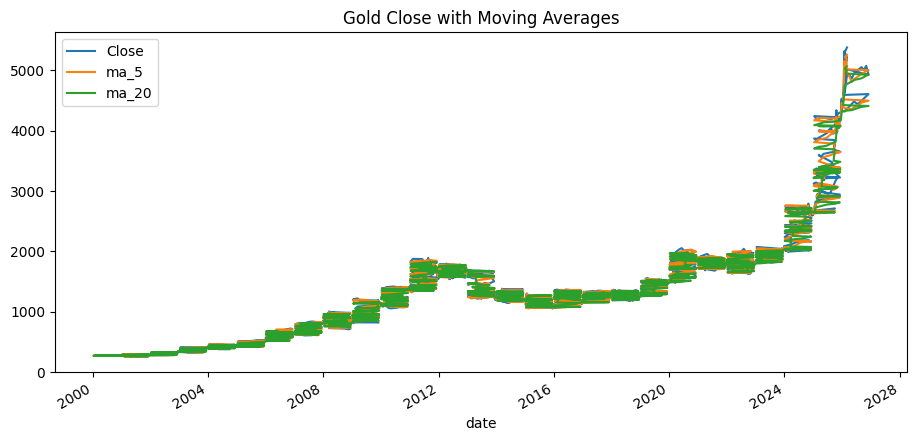

In [13]:
df_model.plot(x="date", y=["Close", "ma_5", "ma_20"], figsize=(11, 5), title="Gold Close with Moving Averages")
plt.show()


## Define features and train-test split

In [15]:
feature_cols = [col for col in df_model.columns if col not in ["date", "target"]]

X = df_model[feature_cols]
y = df_model["target"]

split_idx = int(len(df_model) * 0.80)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Training shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Training shape: (4782, 56) (4782,)
Test shape: (1196, 56) (1196,)


## Preprocessing

In [16]:
numeric_features = X_train.columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features)
])


## Time-aware cross-validation

In [17]:
tscv = TimeSeriesSplit(n_splits=5)
tscv


TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

## Tune baseline models with GridSearchCV

### Logistic Regression

In [18]:
# check only numeric columns
num_cols = X_train.select_dtypes(include=[np.number]).columns

# count inf values by column
inf_counts = pd.Series(
    np.isinf(X_train[num_cols]).sum(axis=0),
    index=num_cols
).sort_values(ascending=False)

print("Columns with inf values:")
print(inf_counts[inf_counts > 0])

# check for very large values too
large_counts = (X_train[num_cols].abs() > 1e10).sum().sort_values(ascending=False)
print("\nColumns with very large values:")
print(large_counts[large_counts > 0])


Columns with inf values:
Series([], dtype: int64)

Columns with very large values:
Series([], dtype: int64)


In [19]:
X_train_clean = X_train.replace([np.inf, -np.inf], np.nan).copy()
X_test_clean = X_test.replace([np.inf, -np.inf], np.nan).copy()


In [20]:
log_reg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

log_reg_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

log_reg_search = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=log_reg_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)

log_reg_search.fit(X_train_clean, y_train)

best_log_reg = log_reg_search.best_estimator_
print(log_reg_search.best_params_)
print(log_reg_search.best_score_)


{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
0.5006704332235443


### Random Forest

In [21]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [4, 8, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 3]
}

rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)

rf_search.fit(X_train_clean, y_train)

best_rf = rf_search.best_estimator_
print(rf_search.best_params_)
print(rf_search.best_score_)


{'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 400}
0.505151367892734


### Gradient Boosting

In [22]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3]
}

gb_search = GridSearchCV(
    estimator=gb_pipe,
    param_grid=gb_grid,
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1
)

gb_search.fit(X_train_clean, y_train)

best_gb = gb_search.best_estimator_
print(gb_search.best_params_)
print(gb_search.best_score_)


{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}
0.5076044253070429


## Build ensemble models

### AdaBoost with Decision Tree base learner

In [23]:
ada_base_tree = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=5,
    random_state=42
)

# Compatibility across sklearn versions:
# newer versions use 'estimator', older versions use 'base_estimator'
try:
    ada_model = AdaBoostClassifier(
        estimator=ada_base_tree,
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
except TypeError:
    ada_model = AdaBoostClassifier(
        base_estimator=ada_base_tree,
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )

ada_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ada_model)
])

ada_pipe.fit(X_train_clean, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Open', 'High', 'Low',
                                                   'Close', 'Volume',
                                                   'avg_sentiment',
                                                   'bullish_count',
                                                   'bearish_count',
                                                   'neutral_count',
                                                   'headline_count',
                                                   'avg_sentiment_confidence',
                                                   'sentiment_3_day',
                                                   'sentiment_7_day',
                                                   'daily...
                                                   'ma_10', 'ma_20',
                                                   'close_vs_ma_5',
                                                   'close_vs_ma_10',
                                                   'close_vs_ma_20',
                                                   'volatility_5',
                                                   'volatility_10',
                                                   'momentum_3', 'momentum_5',
                                                   'momentum_10',
                                                   'volume_change',
                                                   'volume_ma_5',
                                                   'volume_ma_10', ...])])),
                ('model',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                     min_samples_leaf=5,
                                                                     random_state=42),
                                    learning_rate=0.05, n_estimators=200,
                                    random_state=42))])

### Bagging with Decision Tree base learner

In [24]:
bag_base_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

try:
    bagging_model = BaggingClassifier(
        estimator=bag_base_tree,
        n_estimators=200,
        max_samples=0.8,
        max_features=0.8,
        random_state=42
    )
except TypeError:
    bagging_model = BaggingClassifier(
        base_estimator=bag_base_tree,
        n_estimators=200,
        max_samples=0.8,
        max_features=0.8,
        random_state=42
    )

bagging_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", bagging_model)
])

bagging_pipe.fit(X_train_clean, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Open', 'High', 'Low',
                                                   'Close', 'Volume',
                                                   'avg_sentiment',
                                                   'bullish_count',
                                                   'bearish_count',
                                                   'neutral_count',
                                                   'headline_count',
                                                   'avg_sentiment_confidence',
                                                   'sentiment_3_day',
                                                   'sentiment_7_day',
                                                   'daily...
                                                   'close_vs_ma_5',
                                                   'close_vs_ma_10',
                                                   'close_vs_ma_20',
                                                   'volatility_5',
                                                   'volatility_10',
                                                   'momentum_3', 'momentum_5',
                                                   'momentum_10',
                                                   'volume_change',
                                                   'volume_ma_5',
                                                   'volume_ma_10', ...])])),
                ('model',
                 BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5,
                                                                    min_samples_leaf=3,
                                                                    random_state=42),
                                   max_features=0.8, max_samples=0.8,
                                   n_estimators=200, random_state=42))])

### Soft Voting ensemble

In [25]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", clone(best_log_reg)),
        ("rf", clone(best_rf)),
        ("gb", clone(best_gb)),
    ],
    voting="soft"
)

voting_model.fit(X_train_clean, y_train)


VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                Pipeline(steps=[('imputer',
                                                                                                 SimpleImputer(strategy='median')),
                                                                                                ('scaler',
                                                                                                 StandardScaler())]),
                                                                                ['Open',
                                                                                 'High',
                                                                                 'Low',
                                                                                 'Close',
                                                                                 'Volume',
                                                                                 'avg_sentiment',
                                                                                 'bullish_count',
                                                                                 'bearish_count',
                                                                                 'neutral_count',
                                                                                 'headline_count',
                                                                                 'avg_sentiment_confidence',
                                                                                 'sentim...
                                                                                 'daily_return',
                                                                                 'open_close_return',
                                                                                 'high_low_range',
                                                                                 'ma_5',
                                                                                 'ma_10',
                                                                                 'ma_20',
                                                                                 'close_vs_ma_5',
                                                                                 'close_vs_ma_10',
                                                                                 'close_vs_ma_20',
                                                                                 'volatility_5',
                                                                                 'volatility_10',
                                                                                 'momentum_3',
                                                                                 'momentum_5',
                                                                                 'momentum_10',
                                                                                 'volume_change',
                                                                                 'volume_ma_5',
                                                                                 'volume_ma_10', ...])])),
                                              ('model',
                                               GradientBoostingClassifier(learning_rate=0.05,
                                                                          n_estimators=200,
                                                                          random_state=42))]))],
                 voting='soft')

## Evaluation function

In [27]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
    else:
        prob = None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, prob) if prob is not None else np.nan
    }
    return metrics


## Compare models

In [28]:
models = {
    "Best Logistic Regression": best_log_reg,
    "Best Random Forest": best_rf,
    "Best Gradient Boosting": best_gb,
    "AdaBoost": ada_pipe,
    "Bagging": bagging_pipe,
    "Soft Voting": voting_model
    
}

comparison = [evaluate_model(name, model, X_test, y_test) for name, model in models.items()]
comparison_df = pd.DataFrame(comparison).sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_df


,model,accuracy,precision,recall,f1,roc_auc
0,AdaBoost,0.542642,0.550173,0.959276,0.699285,0.526660
1,Bagging,0.547659,0.561000,0.846154,0.674684,0.524805
2,Soft Voting,0.535117,0.555671,0.805430,0.657635,0.520668
3,Best Gradient Boosting,0.522575,0.552273,0.733032,0.629942,0.520076
4,Best Random Forest,0.556020,0.558304,0.953243,0.704178,0.518975
5,Best Logistic Regression,0.515050,0.550425,0.683258,0.609690,0.501385


## Best model diagnostics

In [29]:
best_model_name = comparison_df.loc[0, "model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)


Best model: AdaBoost


In [30]:
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, best_pred))


              precision    recall  f1-score   support

           0       0.33      0.02      0.05       533
           1       0.55      0.96      0.70       663

    accuracy                           0.54      1196
   macro avg       0.44      0.49      0.37      1196
weighted avg       0.45      0.54      0.41      1196



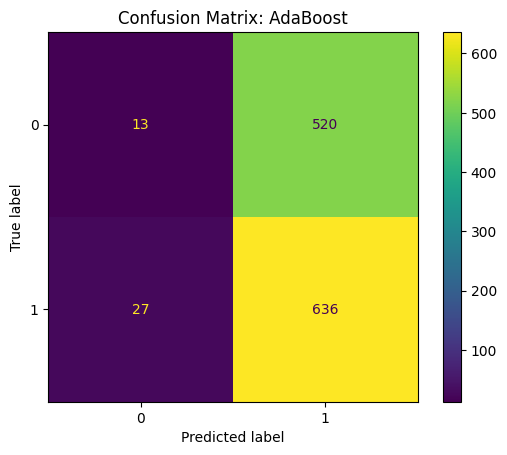

In [31]:
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()




## Results

The results show that ensemble models performed slightly better than Logistic Regression, but overall predictive power remained limited. Random Forest achieved the highest accuracy and F1-score, while AdaBoost produced the highest ROC-AUC. However, all ROC-AUC scores were close to 0.50, indicating weak separation between upward and downward gold price movements. This suggests that gold direction forecasting is difficult using the current feature set, and additional features such as macroeconomic indicators, real sentiment data, interest rates, or dollar index data may be needed to improve performance.

## Next steps

Possible next steps include:

1. Add technical indicators such as RSI, MACD, Bollinger Bands, and ATR.
2. Use `RandomizedSearchCV` for broader hyperparameter search.
3. Add outside market variables such as Treasury yields, CPI, the U.S. dollar index, or VIX.
4. Compare the model with and without artificial sentiment features to measure the exact lift from news sentiment.
5. Test class imbalance strategies if one direction becomes dominant.
6. Reframe the task as regression to predict the next closing price or return.
7. Compare against a naïve benchmark such as always predicting the majority class or always predicting the previous direction.


## Neural Network Model Using Transformer Sentiment Features

This section adds a dense neural network classifier after the transformer sentiment step. 
The transformer converts artificial gold news text into sentiment features, and the neural network learns from both market indicators and sentiment variables to predict gold price direction.

In [32]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Copy merged dataset created earlier
nn_df = df_model.copy()

target_col = "target"

if target_col not in nn_df.columns:
    close_col = "Close"
    nn_df[target_col] = (nn_df[close_col].shift(-1) > nn_df[close_col]).astype(int)
    nn_df = nn_df.iloc[:-1].copy()
    print("Created target from Close.")
else:
    print("Using existing target column: target")

drop_cols = [target_col, "date"]

X = nn_df.drop(columns=drop_cols, errors="ignore")
X = X.select_dtypes(include=[np.number])

y = nn_df[target_col].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)


# Fill remaining missing numeric values with medians.
X = X.fillna(X.median(numeric_only=True))

# Time-aware split: no shuffle, because this is financial time-series data.
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Scale features for neural networks.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tf.random.set_seed(42)

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.25),
    Dense(32, activation='relu'),
    Dropout(0.15),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

y_prob = nn_model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.5).astype(int)

nn_results = {
    'Model': 'Transformer Sentiment + Dense Neural Network',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan,
    'Epochs_Trained': len(history.history['loss'])
}

nn_results_df = pd.DataFrame([nn_results])
display(nn_results_df)
print(classification_report(y_test, y_pred, zero_division=0))


Using existing target column: target
X shape: (5978, 56)
y shape: (5978,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step 


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Epochs_Trained
0,Transformer Sentiment + Dense Neural Network,0.492475,0.559574,0.396682,0.464254,0.49913,13


              precision    recall  f1-score   support

           0       0.45      0.61      0.52       533
           1       0.56      0.40      0.46       663

    accuracy                           0.49      1196
   macro avg       0.50      0.50      0.49      1196
weighted avg       0.51      0.49      0.49      1196



## Neural Network Training Curve

This plot shows training loss and validation loss. If validation loss rises while training loss continues to fall, the model may be overfitting.

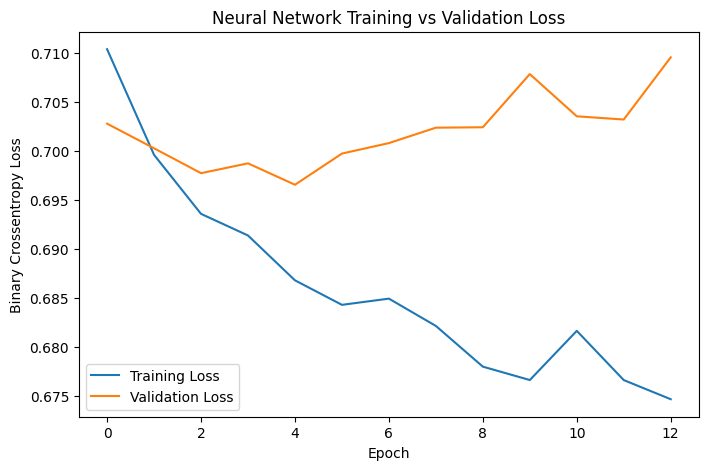

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.show()


## Interpretation

The neural network version creates a hybrid deep learning workflow. First, a transformer neural network reads artificial gold-related headlines and converts text into sentiment scores. Then, a dense neural network combines those sentiment features with numeric gold market features to classify whether the next gold price movement is upward or not. This improves the project because it demonstrates how unstructured text and structured market data can be combined in one predictive pipeline.

The dense neural network underperformed the ensemble tree-based models, achieving 49% accuracy with balanced but weak class metrics. This suggests that for structured financial tabular data, tree ensembles may capture nonlinear relationships more effectively than a basic feedforward neural network. Additional improvements such as deeper architectures, LSTM sequence models, stronger sentiment data, or macroeconomic features may be required for neural networks to outperform ensemble methods.

## Final Model Score Comparison

This final chart compares model performance scores at the end of the notebook. 
It will include the neural network scores and, when available, any earlier model results dataframe created in the project.

In [37]:


models = {
    "Best Logistic Regression": best_log_reg,
    "Best Random Forest": best_rf,
    "Best Gradient Boosting": best_gb,
    "AdaBoost": ada_pipe,
    "Bagging": bagging_pipe,
    "Soft Voting": voting_model
}

# Evaluate sklearn models
comparison = [
    evaluate_model(name, model, X_test, y_test)
    for name, model in models.items()
]

comparison_df = pd.DataFrame(comparison)

# Add neural network results if available
if "nn_results_df" in globals():
    nn_temp = nn_results_df.copy()

    nn_temp = nn_temp.rename(columns={
        "Model": "model",
        "Accuracy": "accuracy",
        "Precision": "precision",
        "Recall": "recall",
        "F1": "f1",
        "ROC_AUC": "roc_auc"
    })

    comparison_df = pd.concat([comparison_df, nn_temp], ignore_index=True)

comparison_df = (
    comparison_df
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

comparison_df


,model,accuracy,precision,recall,f1,roc_auc,Epochs_Trained
0,AdaBoost,0.542642,0.550173,0.959276,0.699285,0.526660,NaN
1,Bagging,0.547659,0.561000,0.846154,0.674684,0.524805,NaN
2,Soft Voting,0.535117,0.555671,0.805430,0.657635,0.520668,NaN
3,Best Gradient Boosting,0.522575,0.552273,0.733032,0.629942,0.520076,NaN
4,Best Random Forest,0.556020,0.558304,0.953243,0.704178,0.518975,NaN
5,Best Logistic Regression,0.515050,0.550425,0.683258,0.609690,0.501385,NaN
6,Transformer Sentiment + Dense Neural Network,0.492475,0.559574,0.396682,0.464254,0.499130,13.0


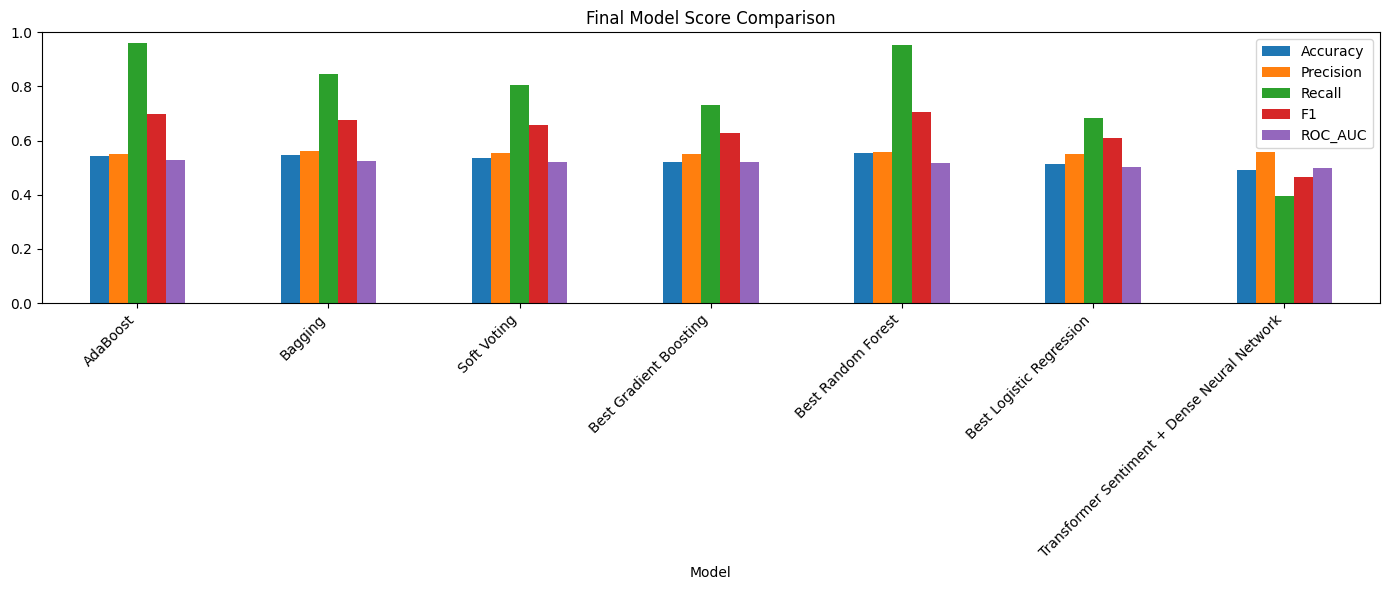

In [38]:
plot_df = comparison_df.rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "ROC_AUC"
})

plot_df.set_index("Model")[["Accuracy","Precision","Recall","F1","ROC_AUC"]].plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Final Model Score Comparison")
plt.ylim(0,1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Final Conclusion

This project explored whether gold price direction can be predicted using machine learning models built on historical market data and sentiment-based features. Multiple classification approaches were tested, including Logistic Regression, Random Forest, Gradient Boosting, AdaBoost, Bagging, Soft Voting ensembles, and a hybrid Transformer plus Neural Network model. The workflow combined structured financial variables such as price behavior, rolling averages, volatility, momentum, volume, and lagged indicators with sentiment features generated from artificial gold-related news text using a transformer model.

The results showed that ensemble tree-based methods performed best overall. Random Forest achieved the strongest accuracy and F1-score, while AdaBoost produced the highest ROC-AUC. However, all ROC-AUC values remained only slightly above 0.50, indicating that the models captured limited predictive signal and that next-day gold direction remains a challenging forecasting task. The neural network model did not outperform the tree-based methods, which suggests that for structured tabular financial data, ensemble models may be more effective than a basic dense neural network architecture.

A key contribution of this project was demonstrating how natural language processing concepts can be integrated into financial modeling. The transformer-based sentiment pipeline showed how unstructured text data can be converted into usable numerical features and combined with traditional technical indicators in a single predictive framework. Even though artificial sentiment data was used for experimentation, the methodology mirrors real-world quantitative finance workflows where news sentiment, earnings commentary, and macroeconomic narratives influence asset prices.

Overall, the project highlights both the potential and limitations of machine learning in financial forecasting. Gold prices are driven by complex macroeconomic forces, investor psychology, and unpredictable external events, making perfect prediction unlikely. Future improvements could include real-world sentiment feeds, macroeconomic variables such as interest rates and inflation, sequence models such as LSTMs, threshold optimization, and additional feature selection. Despite modest predictive performance, the project successfully demonstrated a complete end-to-end machine learning workflow and the value of combining multiple data sources in modern financial analytics.